<a href="https://colab.research.google.com/github/salamlakhan7/sprint-03-deep-learning-nlp-transformers/blob/main/Notebooks/ANN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Artificial Neural Network**

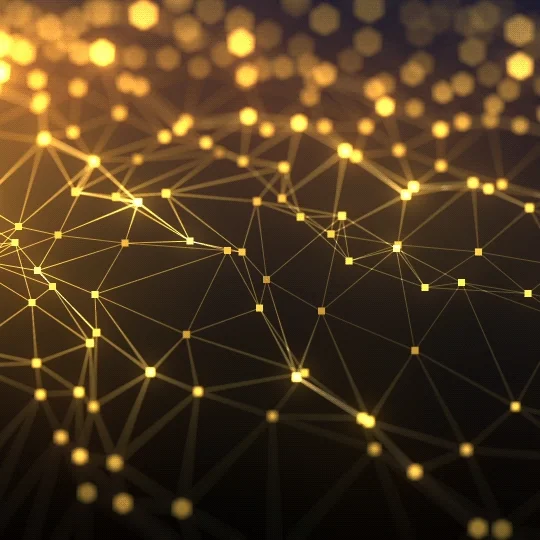 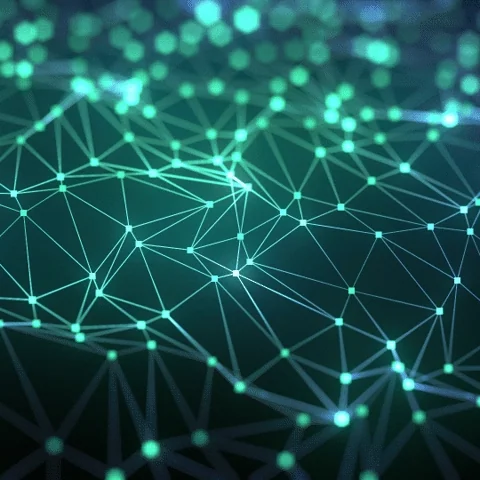

It's the simplest, most basic type of neural network — just layers of neurons stacked one after another, each fully connected to the next (every neuron in one layer talks to every neuron in the next).

 No special tricks yet — no convolution (that's CNN, Days 3-4), no memory of sequences (that's RNN/LSTM, Days 5-6).

 Just: input → hidden layers → output.

This is exactly the neuron/weight/bias/activation stuff we already covered — an ANN is just many of those neurons arranged in layers and trained together.



**Real-life example:** Think of a hiring pipeline with multiple review rounds.

 Round 1 (input layer) looks at the raw resume — every detail, unfiltered.

 Round 2 (hidden layer 1) summarizes: "strong technical background, weak communication."
  
  Round 3 (hidden layer 2) refines further: "good fit for backend, not for sales."
  
  Round 4 (output layer) makes the final call: hire or reject. Each round only sees the *summary* passed from the round before — not the raw resume again.


**Where it fits in what we're building:** We're using MNIST digit images as a simple, well-understood problem to *practice* the ANN mechanics (layers, forward pass, loss, backprop) before adding complexity in later days. The goal isn't "solve MNIST perfectly" — it's "understand every step of training a network by hand."


**Why an ANN specifically for MNIST (and why it won't be the best tool later):** Since ANN treats every pixel as unrelated to its neighbors, it ignores that images have *spatial structure* — a pixel next to another pixel matters. That's fine for MNIST (simple enough), but it's exactly the limitation CNNs (Days 3-4) are built to fix.



## **Step 1 : Loading the Data**

**Concept:** Before a neural network can learn anything, it needs numbers to look at. MNIST is 70,000 images of handwritten digits (0-9), each 28×28 pixels. We split it into training data (to learn from) and validation data (to check if it's actually learning, not memorizing).

**Real-life example:** Think of a student studying for an exam. Training data = practice questions they study from. Validation data = a mock exam they've never seen — it tells you if they actually understood the subject, or just memorized the practice answers.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),          # convert image to tensor
    transforms.Normalize((0.5,), (0.5,))  # scale pixel values to [-1, 1]
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_data   = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 139MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 15.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 171MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]


## **Step 2 : Building the ANN Architecture**

**Concept:** This is where neurons, layers, weights, and bias (which we already covered) actually get assembled into a real network. We flatten each 28×28 image into a single row of 784 numbers, then pass it through layers that shrink down to 10 outputs — one per digit.


**Real-life example:** Back to the loan officer — except now imagine three officers in a chain. The first officer looks at raw evidence and passes a summary to the second. The second officer refines that summary further. The third officer makes the final call: which digit (0-9) is this most likely to be?

In [2]:
class SimpleANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()               # 28x28 image -> 784 numbers
        self.layer1 = nn.Linear(784, 128)          # input layer -> hidden layer 1
        self.layer2 = nn.Linear(128, 64)           # hidden layer 1 -> hidden layer 2
        self.output = nn.Linear(64, 10)            # hidden layer 2 -> output (10 digits)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        return x

model = SimpleANN()

Notice: no activation on the final output layer — that's intentional, the loss function handles it next.

## **Step 3 : Loss Function & Optimizer**

**Concept:** The loss function measures how wrong the model's guess was. The optimizer is what actually adjusts the weights and biases to reduce that wrongness next time.

**Real-life example:** Loss is the officer's manager grading how many loan decisions they got wrong this month. The optimizer is the officer adjusting their own judgment criteria based on that feedback — a little at a time, not overreacting to one mistake.

In [3]:
criterion = nn.CrossEntropyLoss()          # loss function for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)   # adjusts weights/bias

# lr=0.001 is the learning rate — how big a step the optimizer takes each correction.
#  Too high and it overshoots, too low and it learns painfully slowly.

## **Step 4 : The Training Loop**

**Concept:** This is the actual Input → Model → Prediction → Loss → Learning cycle, written out by hand — no .fit() hiding it.

**Real-life example:** The officer reviews a batch of applications, makes decisions, gets told how many were wrong, then updates their criteria — then repeats with the next batch. One full pass through all batches = one "epoch."

In [4]:
def train_one_epoch():
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()              # clear old gradients
        outputs = model(images)            # forward pass -> prediction
        loss = criterion(outputs, labels)  # how wrong was it?
        loss.backward()                    # backpropagation -> compute gradients
        optimizer.step()                   # update weights & bias
        total_loss += loss.item()
    return total_loss / len(train_loader)

## **Step 5 : Validation Loop**

**Concept:** Same idea as training, but no learning happens — no optimizer.step(). We're just checking performance on data the model hasn't trained on.

**Real-life example:** The mock exam. The student answers questions, but nothing they write changes what they already know — it just reveals how well they actually learned.

In [6]:
def validate():
    model.eval()
    total_loss = 0
    with torch.no_grad():        # no gradient tracking needed for validation
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    return total_loss / len(val_loader)

## **Step 6 : Running It & Tracking Loss**

In [7]:
epochs = 5
for epoch in range(epochs):
    train_loss = train_one_epoch()
    val_loss = validate()
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

Epoch 1: train_loss=0.4036, val_loss=0.2388
Epoch 2: train_loss=0.1983, val_loss=0.1582
Epoch 3: train_loss=0.1441, val_loss=0.1272
Epoch 4: train_loss=0.1144, val_loss=0.1017
Epoch 5: train_loss=0.0981, val_loss=0.1042


Watch what happens to val_loss across epochs — if it starts climbing while train_loss keeps dropping, that's overfitting (the "student memorized the practice questions" problem).

## **Interpreting Results First**

Good numbers - let's read them before moving on, since the shape of the curve tells a real story:


| Epoch | train_loss | val_loss |
|---|---|---|
| 1 | 0.4036 | 0.2388 |
| 2 | 0.1983 | 0.1582 |
| 3 | 0.1441 | 0.1272 |
| 4 | 0.1144 | 0.1017 |
| 5 | 0.0981 | **0.1042** ⬆ |


**Real-life example:** Remember the student and the mock exam? Epochs 1-4, both practice-question scores (train_loss) and mock-exam scores (val_loss) improve together - genuine learning.

But at Epoch 5, train_loss kept dropping while val_loss ticked *up* slightly (0.1017 → 0.1042).

That's the earliest sign of the student starting to memorize practice questions rather than understanding the material — the first whisper of overfitting. It's tiny here, not a real problem yet, but it's exactly the pattern to watch for.

## **Step 7 - Accuracy (not just loss)**

**Concept:** Loss tells you how confident and correct the model's probabilities were — but it's abstract. Accuracy tells you the number people actually care about: out of 10,000 validation digits, how many did it get right?

**Real-life example:** Loss is like a professor's overall impression from grading. Accuracy is the raw "8 out of 10 answers correct" — the number you'd actually tell someone.

In [8]:
def accuracy():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)  # pick highest-scoring digit
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total

print(f"Validation accuracy: {accuracy()*100:.2f}%")

Validation accuracy: 96.59%


## **Step 8  Plot Train vs Val Loss**

**Concept**: Numbers in a table are hard to spot trends in. A graph makes the overfitting moment (like your Epoch 5 uptick) visually obvious.

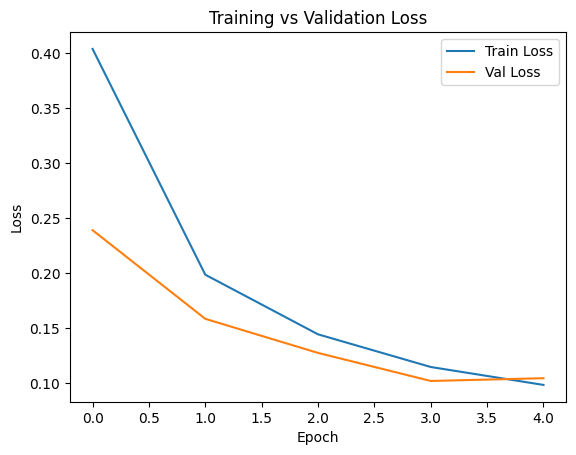

In [9]:
import matplotlib.pyplot as plt

train_losses = [0.4036, 0.1983, 0.1441, 0.1144, 0.0981]
val_losses   = [0.2388, 0.1582, 0.1272, 0.1017, 0.1042]

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

**## Step 9 - Save the Trained Model**

In [11]:
torch.save(model.state_dict(), './models/simple_ann_mnist.pth')

## **Step 10 : Test on Your Own Digit**

**Concept:** MNIST images are very specific: 28×28 pixels, grayscale, white digit on black background, centered. Any photo you upload won't match that automatically — so we need to preprocess it to look like MNIST before feeding it to the model.

**Real-life example:** It's like translating a foreign document before a person who only reads English can review it. The model only "understands" MNIST-format images — anything else needs converting first, or it'll misread it, no matter how good the model actually is.

In [12]:
from PIL import Image
import torch
from torchvision import transforms

# Load your trained model
model = SimpleANN()
model.load_state_dict(torch.load('./models/simple_ann_mnist.pth'))
model.eval()

def predict_digit(image_path):
    img = Image.open(image_path).convert('L')          # convert to grayscale
    img = img.resize((28, 28))                          # match MNIST size

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    img_tensor = transform(img).unsqueeze(0)             # add batch dimension

    with torch.no_grad():
        output = model(img_tensor)
        prediction = torch.argmax(output, dim=1).item()
        confidence = torch.softmax(output, dim=1).max().item()

    print(f"Predicted digit: {prediction} (confidence: {confidence*100:.2f}%)")
    return prediction

One important catch: MNIST digits are white on black. If your photo is a normal handwritten digit — black ink on white paper — you need to invert it first, or the model will likely misread it (since it's never seen that pattern):

In [18]:
from PIL import ImageOps

img = Image.open("./ANN_test.jfif").convert('L')
img = ImageOps.invert(img)   # flip black<->white if your photo is dark-on-light
img = img.resize((28, 28))
predict_digit("ANN_test.jfif")

Predicted digit: 3 (confidence: 83.84%)


3



**What happened:** The model got it right (3), but confidence dropped hard — from the ~96-99% certainty it typically shows on clean MNIST digits, down to 83.84% here. That gap is the noise/stardust texture doing exactly what we expected: throwing off a model that has zero concept of "ignore the background clutter, focus on the shape."

**Real-life example, one more time:** Think of the loan officer again — trained entirely on clean, well-organized applications. Now hand them a messy, coffee-stained, hastily-scanned form with the same information buried in it. They probably still get the right answer, but they hesitate more, less sure of themselves. Same officer, same judgment, but noisier input erodes confidence even when the final call is still correct.

**Why this happens technically:** Remember — ANN flattens the image into 784 independent numbers and treats each pixel as unrelated to its neighbors. It has no idea that a stray white dot in the corner is "background noise" versus "part of the digit" — it just sees a number that's different from what it saw during training, pixel by pixel. It got lucky here because the "3" shape itself was still strong enough to dominate, but push the noise further and it likely breaks.

**This is bridge into Days 3-4 (CNNs):** A CNN uses convolution filters that scan for local *patterns* (edges, curves) rather than memorizing exact pixel positions — which is exactly the property that makes it far more robust to noise and pixel-shifting like this. You just personally demonstrated the ANN's core weakness with your own test image, which is the best way to actually feel why CNNs exist.

